<a href="https://colab.research.google.com/github/koustav241013006127tiu/AI-Python/blob/main/labproblem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Route A to C: True
Route A to E: False

Connected Components:
Component 1 : ['A', 'B', 'C']
Component 2 : ['D', 'E']
Component 3 : ['F', 'G']


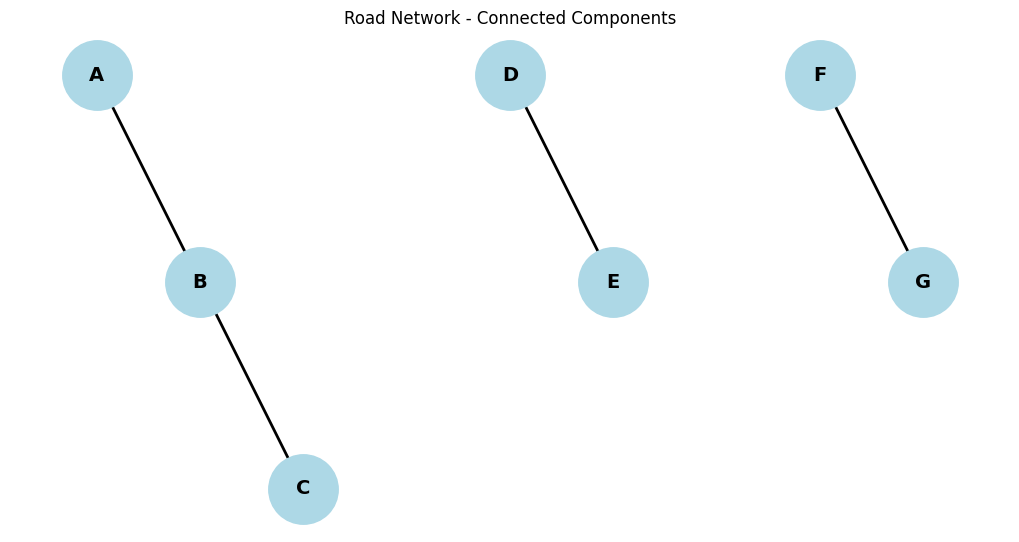

In [1]:
import networkx as nx
import matplotlib.pyplot as plt


# Road network
graph = {
    'A': ['B'],
    'B': ['A', 'C'],
    'C': ['B'],
    'D': ['E'],
    'E': ['D'],
    'F': ['G'],
    'G': ['F']
}


# Check whether route exists
def route_exists(graph, start, destination):
    visited = set()

    def dfs(city):
        if city == destination:
            return True

        visited.add(city)

        for neighbour in graph[city]:
            if neighbour not in visited:
                if dfs(neighbour):
                    return True

        return False

    return dfs(start)


# Find connected components
def connected_components(graph):
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            component = []

            def dfs(city):
                visited.add(city)
                component.append(city)

                for neighbour in graph[city]:
                    if neighbour not in visited:
                        dfs(neighbour)

            dfs(city)
            components.append(component)

    return components


# Check routes
print("Route A to C:", route_exists(graph, 'A', 'C'))
print("Route A to E:", route_exists(graph, 'A', 'E'))


# Find connected components
print("\nConnected Components:")

components = connected_components(graph)

for i, component in enumerate(components, 1):
    print("Component", i, ":", component)


# --------------------------------
# Draw Road Network Diagram
# --------------------------------

G = nx.Graph()

# Add nodes and roads
for city in graph:
    G.add_node(city)

    for neighbour in graph[city]:
        G.add_edge(city, neighbour)


# Position of cities
pos = {
    'A': (0, 2),
    'B': (1, 1),
    'C': (2, 0),

    'D': (4, 2),
    'E': (5, 1),

    'F': (7, 2),
    'G': (8, 1)
}


# Draw graph
plt.figure(figsize=(10, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color='lightblue',
    font_size=14,
    font_weight='bold',
    width=2
)

plt.title("Road Network - Connected Components")
plt.axis('off')
plt.show()